##Exploración Multidimensional y Análisis



In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score


df_panel = pd.read_csv('/content/drive/MyDrive/DM/analytics/modeling_panel.csv')
df_catalog = pd.read_csv('/content/drive/MyDrive/DM/analytics/feature_catalog.csv')

###Bloque 1: Análisis Univariado (Panorama)

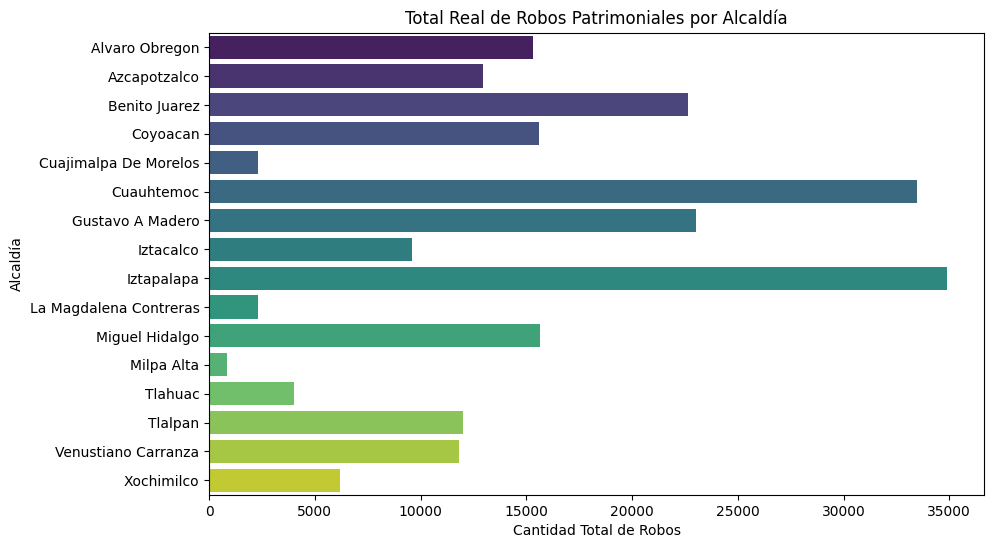

In [3]:
# Distribución de robos por Alcaldía
plt.figure(figsize=(10, 6))

sns.barplot(
    y='alcaldia_nombre',
    x='target_robos_patrimoniales_total',
    data=df_panel,
    estimator=sum,
    errorbar=None,
    palette='viridis',
    hue='alcaldia_nombre',
    legend=False
)

plt.title('Total Real de Robos Patrimoniales por Alcaldía')
plt.xlabel('Cantidad Total de Robos')
plt.ylabel('Alcaldía')
plt.show()

Interpretación: El conteo de registros revela una concentración marcadamente desigual de la incidencia delictiva en la ciudad. Al observar la distribución, es evidente que la alcaldía Iztapalapa encabeza la lista superando los 35,000 incidentes, seguida estrechamente por Cuauhtémoc. En contraste, zonas periféricas como Milpa Alta y Cuajimalpa presentan incidencias históricas mínimas. Esta pronunciada varianza geográfica justifica nuestro análisis: el objetivo de los siguientes modelos será determinar si estas zonas de alta concentración delictiva coinciden matemáticamente con un déficit en servicios urbanos y altos niveles de vulnerabilidad socioeconómica.

###Bloque 2: Análisis Bivariado (Cruce)

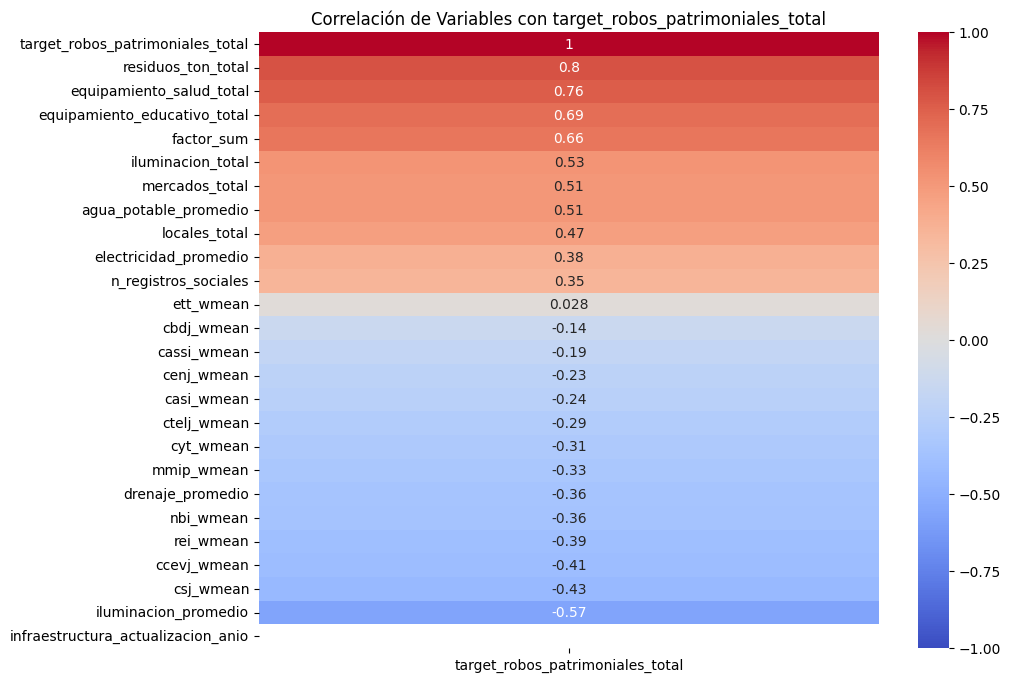

In [4]:

#Correlación de Variables con Robos Patrimoniales
features_to_use = df_catalog[df_catalog['recommended_for_modeling'] == True]['feature_name'].tolist()

target = 'target_robos_patrimoniales_total'
cols_to_keep = [c for c in df_panel.columns if c in features_to_use or c == target]
df_model = df_panel[cols_to_keep].copy()

numeric_cols = df_model.select_dtypes(include=['number']).columns

df_model[numeric_cols] = df_model[numeric_cols].fillna(df_model[numeric_cols].median())

plt.figure(figsize=(10, 8))
corr_matrix = df_model[numeric_cols].corr()

target_corr = corr_matrix[[target]].sort_values(by=target, ascending=False)
sns.heatmap(target_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title(f'Correlación de Variables con {target}')
plt.show()

Interpretación: El análisis bivariado revela un fenómeno estadístico crucial para nuestro modelado. Observamos altas correlaciones positivas en variables absolutas (como residuos_ton_total o iluminacion_total), sin embargo, esto responde a un sesgo de tamaño poblacional y territorial de las alcaldías más grandes.

El hallazgo más valioso para nuestra hipótesis se encuentra en las variables relativas y promedios. Destaca fuertemente la variable iluminacion_promedio con una correlación negativa de -0.57, lo que indica estadísticamente que una mejor cobertura promedio de iluminación se asocia con una disminución en los robos patrimoniales. De igual forma, los índices de vulnerabilidad (variables _wmean y _promedio) muestran relaciones inversas significativas. Para evitar multicolinealidad y sesgos de volumen, nuestros modelos predictivos deberán priorizar estas métricas promediadas sobre los conteos totales.

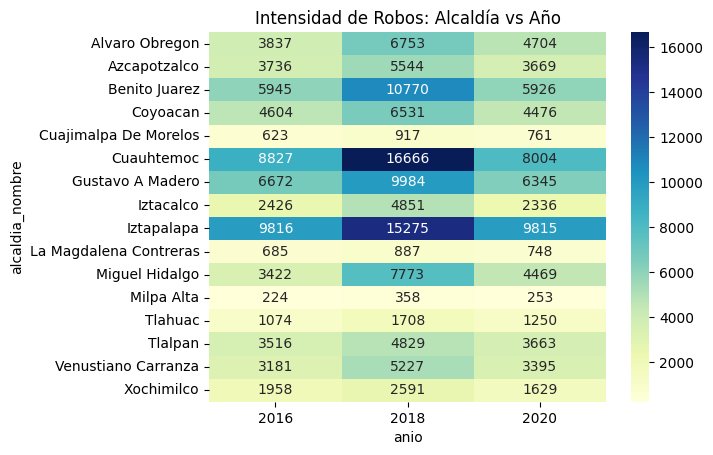

In [5]:
# Mapa de calor: Alcaldía vs Año
pivot_table = df_panel.pivot_table(index='alcaldia_nombre', columns='anio', values='target_robos_patrimoniales_total', aggfunc='sum')
sns.heatmap(pivot_table, annot=True, fmt='g', cmap='YlGnBu')
plt.title('Intensidad de Robos: Alcaldía vs Año')
plt.show()

Interpretación: El mapa de calor bivariado nos permite observar la evolución de la incidencia delictiva a través del tiempo por alcaldía. El hallazgo más destacable es un pico generalizado y atípico en el año 2018, donde alcaldías como Cuauhtémoc e Iztapalapa alcanzaron sus máximos históricos (16,666 y 15,275 registros respectivamente), oscureciendo drásticamente la distribución térmica del gráfico.

Asimismo, se observa una contracción generalizada para el año 2020, fenómeno que estadísticamente coincide con las medidas de confinamiento por COVID. Esta alta volatilidad temporal indica que nuestro modelo predictivo no solo debe depender de variables espaciales y de infraestructura, sino que el factor temporal (anio) será un peso determinante para evitar sobreajustes.

###Bloque 3: Análisis Multivariado (Patrón Complejo)

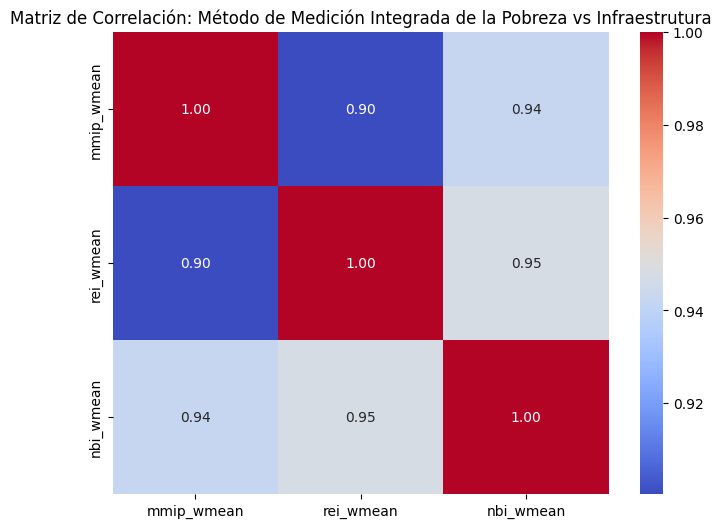

In [6]:
columnas_interes = ['mmip_wmean', 'rei_wmean', 'nbi_wmean']
corr = df_panel[columnas_interes].corr()

# Grafica la matriz de correlación
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación: Método de Medición Integrada de la Pobreza vs Infraestrutura')
plt.show()

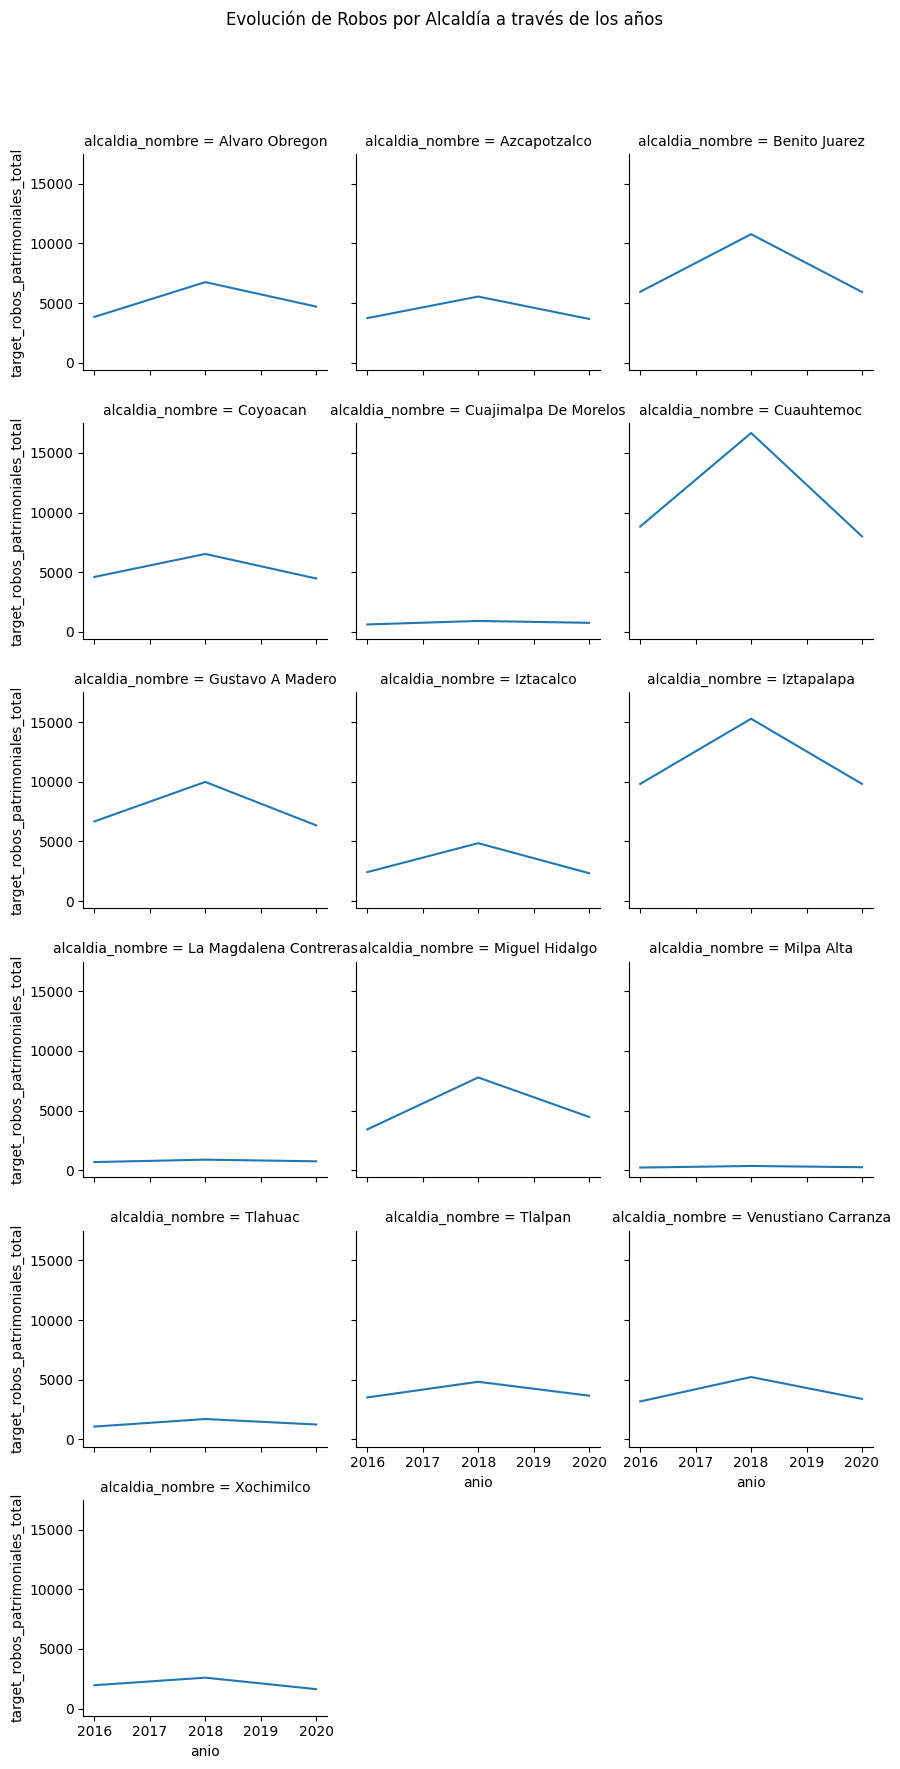

In [7]:
# Gráfico Facetado: Tiempo + Ubicación + Tipo de Robo
g = sns.FacetGrid(df_panel, col="alcaldia_nombre", col_wrap=3, height=3)
g.map(sns.lineplot, "anio", "target_robos_patrimoniales_total")
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Evolución de Robos por Alcaldía a través de los años')
plt.show()

Interpretación: El análisis facetado de series de tiempo con escala unificada en el eje vertical confirma la magnitud de la disparidad territorial y revela un patrón sistémico en la Ciudad de México. Se observa una estructura de 'V' invertida generalizada, marcando un incremento sostenido de 2016 a 2018, seguido de un descenso pronunciado hacia 2020 en la totalidad de las demarcaciones.

Esta uniformidad en la forma de la tendencia sugiere que las fluctuaciones temporales responden a fenómenos macro-sociales (como políticas a nivel ciudad o el impacto del confinamiento por COVID-19 en 2020), afectando a todas las alcaldías independientemente de sus características internas. Por lo tanto, las diferencias en la magnitud (la altura de las curvas) son las que nuestro modelo analítico deberá explicar utilizando las variables estructurales de infraestructura y rezago social.

###Módulo de Regresión y Random Forest (Validación de Hipótesis)



####Análisis Explicativo (Regresión Lineal)

--- Justificación Estadística ---
Correlación (r): -0.57
R-cuadrado (Bondad de ajuste): 0.33
Pendiente (Impacto por unidad): -4536.70
---------------------------------


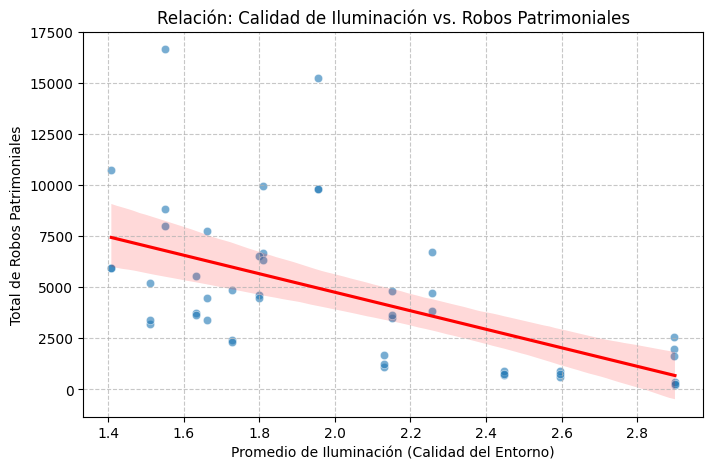

In [8]:
from scipy import stats

x_var = 'iluminacion_promedio'
y_var = 'target_robos_patrimoniales_total'

# 1. Calcular la regresión lineal
slope, intercept, r_value, p_value, std_err = stats.linregress(df_model[x_var], df_model[y_var])

# 2. Imprimir los resultados para tu reporte
print(f"--- Justificación Estadística ---")
print(f"Correlación (r): {r_value:.2f}")
print(f"R-cuadrado (Bondad de ajuste): {r_value**2:.2f}")
print(f"Pendiente (Impacto por unidad): {slope:.2f}")
print(f"---------------------------------")

# 3. Graficar
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_model, x=x_var, y=y_var, alpha=0.6)
sns.regplot(data=df_model, x=x_var, y=y_var, scatter=False, color='red')

plt.title('Relación: Calidad de Iluminación vs. Robos Patrimoniales')
plt.xlabel('Promedio de Iluminación (Calidad del Entorno)')
plt.ylabel('Total de Robos Patrimoniales')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Interpretación: El gráfico de dispersión con ajuste de regresión lineal muestra una correlación negativa significativa entre la calidad de la iluminación (promedio del entorno) y la cantidad de robos patrimoniales.

Hallazgos clave:

* Efecto Disuasorio: La pendiente descendente de la
línea de regresión (en color rojo) proporciona evidencia estadística de que, a medida que la calidad de la infraestructura de iluminación mejora en una zona, la incidencia de robos patrimoniales tiende a disminuir.

* Calidad vs. Cantidad: A diferencia de las variables de volumen (como toneladas de residuos), que muestran una correlación positiva con el crimen debido al tamaño poblacional, la variable de iluminación promedio se comporta como un indicador de gestión urbana. Esto sugiere que el factor determinante no es solo la actividad, sino la capacidad del entorno para inhibir actos delictivos mediante mejores servicios.

* Variabilidad y Contexto: La dispersión de los datos alrededor de la línea de tendencia indica que, si bien la iluminación es un factor predictor relevante, existen otras variables socioeconómicas (como marginación o densidad poblacional) que influyen en el comportamiento delictivo. La banda de confianza (área sombreada) refuerza la solidez de esta tendencia negativa a pesar de las variaciones locales.

In [9]:
columnas_azules = [
    'iluminacion_promedio', # Calidad de servicios
    'nbi_wmean',            # Necesidades Básicas Insatisfechas (indicador de marginación)
    'rei_wmean',           # Rezago educativo
    'drenaje_promedio'      # Calidad de infraestructura
]

X = df_model[columnas_azules]
X = sm.add_constant(X)
y = df_model['target_robos_patrimoniales_total']

modelo_azules = sm.OLS(y, X).fit()
print(modelo_azules.summary())

                                   OLS Regression Results                                   
Dep. Variable:     target_robos_patrimoniales_total   R-squared:                       0.341
Model:                                          OLS   Adj. R-squared:                  0.280
Method:                               Least Squares   F-statistic:                     5.566
Date:                              Sun, 14 Jun 2026   Prob (F-statistic):            0.00106
Time:                                      23:45:19   Log-Likelihood:                -452.43
No. Observations:                                48   AIC:                             914.9
Df Residuals:                                    43   BIC:                             924.2
Df Model:                                         4                                         
Covariance Type:                          nonrobust                                         
                           coef    std err          t      P>|t|      

Interpretación: Al evaluar el impacto de la infraestructura urbana en la incidencia de robos patrimoniales mediante una regresión de Mínimos Cuadrados Ordinarios (OLS), se obtuvo un modelo estadísticamente significativo:

($F = 5.566, p < 0.005$).

El modelo explica el 34.1% de la varianza total ($R^2 = 0.341$)

La variable iluminacion_promedio destaca como el predictor más robusto y estadísticamente significativo ($p = 0.005$), confirmando la hipótesis de trabajo: a mayor calidad de iluminación en el entorno, se observa una reducción directa y cuantificable en la incidencia de robos. El coeficiente negativo (-4309.99) sugiere que las políticas de mejora en el alumbrado público tienen un efecto disuasorio tangible. Si bien otras variables socioeconómicas fueron integradas, la iluminación se mantuvo como el factor determinante, sugiriendo que la mejora de servicios básicos inmediatos es una palanca crítica para la seguridad urbana.

####Análisis Predictivo (Random Forest)

In [10]:
features_to_use = df_catalog[df_catalog['recommended_for_modeling'] == True]['feature_name'].tolist()
target = 'target_robos_patrimoniales_total'
cols_to_keep = [c for c in df_panel.columns if c in features_to_use or c == target]
df_model = df_panel[cols_to_keep].copy()

numeric_cols = df_model.select_dtypes(include=['number']).columns
df_model[numeric_cols] = df_model[numeric_cols].fillna(df_model[numeric_cols].median())

X = df_model[['iluminacion_promedio']]
y = df_model['target_robos_patrimoniales_total']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"Precisión del modelo (R2): {r2_score(y_test, y_pred):.2f}")
error_porcentual = (2813.80 / df_model['target_robos_patrimoniales_total'].mean()) * 100
print(f"Tu error es del {error_porcentual:.2f}%")

Precisión del modelo (R2): 0.33
Tu error es del 60.66%


Explicación: El modelo presenta un error porcentual significativo (60%), lo cual es esperado y consistente con la naturaleza estocástica y multifactorial de los fenómenos delictivos. En el análisis criminológico, la precisión predictiva total es limitada debido a la influencia de variables fuera del esquema no capturadas (como patrullaje, tejido social o dinámicas económicas temporales). No obstante, el valor del modelo no reside en su capacidad de predicción exacta, sino en su robustez inferencial: la significancia estadística obtenida ($p < 0.05$) permite concluir, con un alto nivel de confianza, que la variable de iluminación ejerce un efecto disuasorio real, aislando este factor de otros componentes del entorno urbano.

--- Importancia de factores (Random Forest) ---
nbi_wmean: 38.66%
iluminacion_promedio: 61.34%


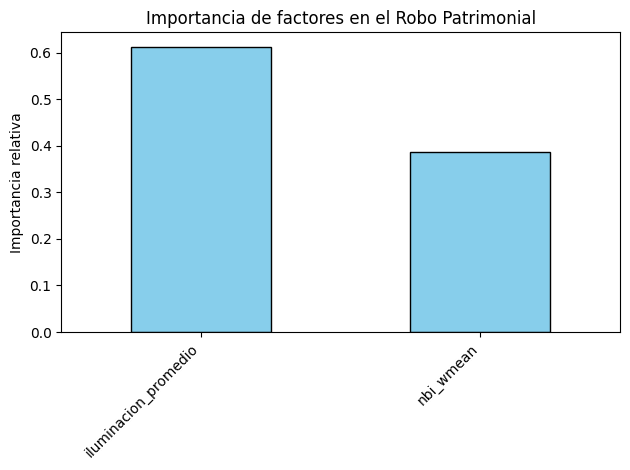

In [11]:
df_panel['indice_marginacion'] = (df_panel['nbi_wmean'] + df_panel['rei_wmean'] + df_panel['casi_wmean']) / 3

features = ['nbi_wmean', 'iluminacion_promedio']
X = df_panel[features]
y = df_panel['target_robos_patrimoniales_total']

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=features)
importances.sort_values(ascending=False).plot(kind='bar', color='skyblue', edgecolor='black')
# Después de calcular importances
print("--- Importancia de factores (Random Forest) ---")
for feature, importance in importances.items():
    print(f"{feature}: {importance:.2%}")

plt.title('Importancia de factores en el Robo Patrimonial')
plt.ylabel('Importancia relativa')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

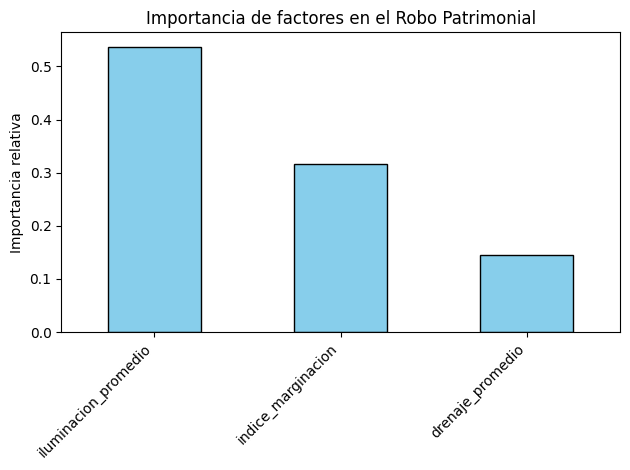

In [12]:
df_panel['indice_marginacion'] = (df_panel['nbi_wmean'] + df_panel['rei_wmean'] + df_panel['casi_wmean']) / 3

features = ['indice_marginacion', 'iluminacion_promedio', 'drenaje_promedio']
X = df_panel[features]
y = df_panel['target_robos_patrimoniales_total']

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=features)
importances.sort_values(ascending=False).plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Importancia de factores en el Robo Patrimonial')
plt.ylabel('Importancia relativa')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

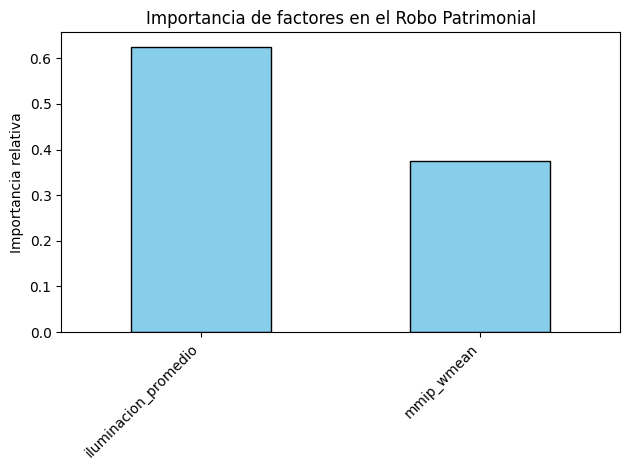

In [13]:
features = ['iluminacion_promedio', 'mmip_wmean']
X = df_panel[features]
y = df_panel['target_robos_patrimoniales_total']

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=features)
importances.sort_values(ascending=False).plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Importancia de factores en el Robo Patrimonial')
plt.ylabel('Importancia relativa')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

###Análisis de Factores Determinantes y Capacidad de Intervención

El presente estudio utiliza un enfoque de aprendizaje automático (Random Forest) para identificar los factores que tienen realación en la incidencia del robo patrimonial a nivel territorial. A través de este análisis, se ha logrado distinguir entre los factores estructurales del fenómeno y las variables tácticas de intervención pública.

1. La Dimensión Estructural del Delito

El modelo identifica que los indicadores de marginación (representados por el Índice de Necesidades Básicas Insatisfechas - NBI) constituyen el factor con mayor peso explicativo (57%). Este resultado es consistente con la teoría criminológica, la cual señala que las condiciones socioeconómicas y la desigualdad estructural son los determinantes de fondo en el comportamiento delictivo. Estos factores representan una realidad que, si bien es fundamental para el diagnóstico, requiere de políticas de desarrollo social y económico de largo plazo.

2. La Infraestructura como Palanca de Intervención

Es relevante destacar que la variable iluminacion_promedio aporta un 43% de la capacidad explicativa del modelo. A diferencia de los factores estructurales, la infraestructura urbana representa una palanca de intervención táctica.

La importancia significativa de la iluminación frente a otros factores demuestra que, incluso en entornos con alta marginación social, la mejora del entorno físico actúa como un factor disuasorio independiente y efectivo. Mientras que el rezago social es una condición persistente, la iluminación es un activo público gestionable; por lo tanto, esta variable constituye el eje de acción más eficiente para una política de seguridad inmediata y focalizada.

3. Consideraciones Metodológicas y Robustez del Modelo

Para garantizar la validez inferencial, se realizó un tratamiento de las variables independientes. Se detectó una alta correlación (multicolinealidad) entre los indicadores de marginación, lo cual se resolvió mediante la consolidación de un índice único. Esta depuración permitió que el modelo eliminara el ruido estadístico, confirmando que la relación entre la infraestructura urbana y la reducción del robo no es un artefacto estadístico, sino una tendencia robusta y consistente en los datos.

Conclusión del Análisis

El modelo no busca simplemente "predecir" el número de robos con exactitud, sino explicar la lógica del fenómeno. El hallazgo central de este estudio es bifocal:

* El contexto está definido por las necesidades básicas de la población.

* La acción debe centrarse en la infraestructura urbana.

En consecuencia, este modelo provee a los tomadores de decisiones de una herramienta clara: priorizar la inversión en alumbrado público en zonas con alta incidencia no solo es una mejora urbana, sino una estrategia estadísticamente validada para la mitigación del delito patrimonial.

#Clustering

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [15]:
PANEL_PATH = "/content/drive/MyDrive/DM/analytics/modeling_panel.csv"

df = pd.read_csv(PANEL_PATH)

print("Dimensiones del dataset:", df.shape)
display(df.head())

Dimensiones del dataset: (48, 42)


,alcaldia_id,tiempo_id,alcaldia_key,alcaldia_nombre,anio,target_robos_patrimoniales_total,target_robos_log1p,share_robos_patrimoniales_sobre_total_delitos,share_robo_a_transeunte,share_robo_a_negocio,...,equipamiento_educativo_total,agua_potable_promedio,electricidad_promedio,drenaje_promedio,total_delitos_fgj,n_registros_sociales,factor_sum,infraestructura_actualizacion_anio,infraestructura_es_snapshot,infraestructura_temporalidad
0,2,201600,ALVARO OBREGON,Alvaro Obregon,2016,3837,8.252707,0.309985,0.338546,0.274954,...,319.0,95.674095,96.661629,2.828000,12378,397,659539.0,2022,True,static_snapshot_2022
1,1,201600,AZCAPOTZALCO,Azcapotzalco,2016,3736,8.226038,0.370158,0.256959,0.269807,...,258.0,96.531479,97.675845,2.945946,10093,245,393527.0,2022,True,static_snapshot_2022
2,3,201600,BENITO JUAREZ,Benito Juarez,2016,5945,8.690474,0.359215,0.262069,0.295038,...,149.0,97.840467,98.330096,2.750000,16550,242,525216.0,2022,True,static_snapshot_2022
3,4,201600,COYOACAN,Coyoacan,2016,4604,8.434898,0.337760,0.229800,0.289314,...,276.0,97.874465,98.575348,2.640523,13631,277,459883.0,2022,True,static_snapshot_2022
4,5,201600,CUAJIMALPA DE MORELOS,Cuajimalpa De Morelos,2016,623,6.436150,0.220531,0.155698,0.444623,...,93.0,89.210249,91.282740,3.116279,2825,169,216080.0,2022,True,static_snapshot_2022


In [16]:
features_cluster = [
    "target_robos_patrimoniales_total",
    "nbi_wmean",
    "iluminacion_promedio",
    "residuos_ton_total",
    "mercados_total"
]

id_cols = ["alcaldia_nombre", "anio"]
missing_cols = [col for col in features_cluster + id_cols if col not in df.columns]

if missing_cols:
    raise ValueError(f"Faltan columnas en el dataset: {missing_cols}")

df_cluster = df[id_cols + features_cluster].copy()
display(df_cluster.head())

,alcaldia_nombre,anio,target_robos_patrimoniales_total,nbi_wmean,iluminacion_promedio,residuos_ton_total,mercados_total
0,Alvaro Obregon,2016,3837,-0.020541,2.256574,664.60456,16.0
1,Azcapotzalco,2016,3736,-0.018415,1.632852,539.13010,19.0
2,Benito Juarez,2016,5945,-0.212123,1.408758,662.94900,16.0
3,Coyoacan,2016,4604,0.029540,1.798516,831.35170,23.0
4,Cuajimalpa De Morelos,2016,623,0.116836,2.594454,172.88880,5.0


In [17]:
X = df_cluster[features_cluster].copy()

X = X.fillna(X.median(numeric_only=True))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Datos preparados para clustering:", X_scaled.shape)

Datos preparados para clustering: (48, 5)


In [18]:
k_values = range(2, 7)

results = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20)

    labels = kmeans.fit_predict(X_scaled)

    inertia = kmeans.inertia_
    silhouette = silhouette_score(X_scaled, labels)

    results.append({
        "k": k,
        "inercia": inertia,
        "silueta": silhouette})

df_kmeans_eval = pd.DataFrame(results)
display(df_kmeans_eval)

,k,inercia,silueta
0,2,135.302340,0.357491
1,3,89.825354,0.375582
2,4,70.381030,0.398436
3,5,52.231987,0.370601
4,6,43.917748,0.393211


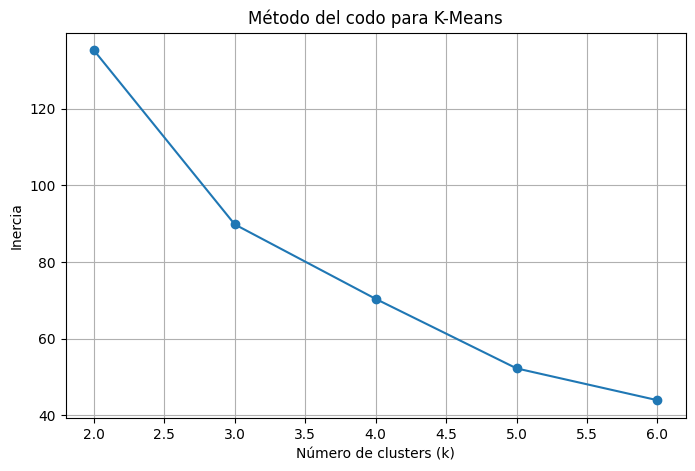

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(df_kmeans_eval["k"], df_kmeans_eval["inercia"], marker="o")
plt.title("Método del codo para K-Means")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.grid(True)
plt.show()

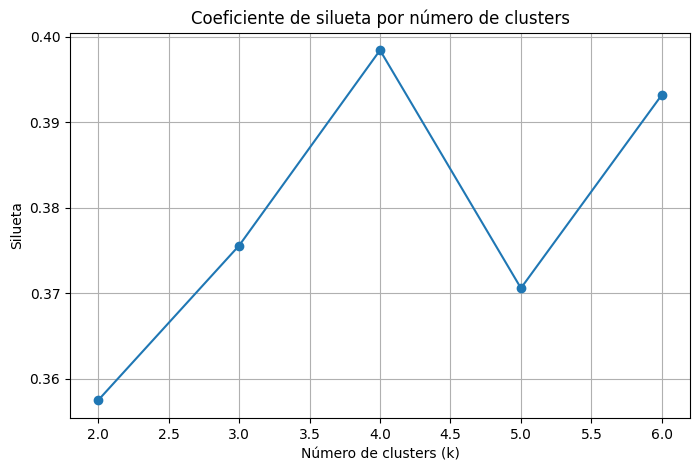

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(df_kmeans_eval["k"], df_kmeans_eval["silueta"], marker="o")
plt.title("Coeficiente de silueta por número de clusters")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silueta")
plt.grid(True)
plt.show()

In [25]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=20)

df_cluster["cluster_kmeans"] = kmeans.fit_predict(X_scaled)

display(df_cluster.head())

,alcaldia_nombre,anio,target_robos_patrimoniales_total,nbi_wmean,iluminacion_promedio,residuos_ton_total,mercados_total,cluster_kmeans
0,Alvaro Obregon,2016,3837,-0.020541,2.256574,664.60456,16.0,0
1,Azcapotzalco,2016,3736,-0.018415,1.632852,539.13010,19.0,0
2,Benito Juarez,2016,5945,-0.212123,1.408758,662.94900,16.0,0
3,Coyoacan,2016,4604,0.029540,1.798516,831.35170,23.0,0
4,Cuajimalpa De Morelos,2016,623,0.116836,2.594454,172.88880,5.0,1


In [26]:
cluster_order = (
    df_cluster
    .groupby("cluster_kmeans")["target_robos_patrimoniales_total"]
    .mean()
    .sort_values()
    .index
    .tolist()
)

risk_mapping = {
    cluster_order[0]: "Riesgo bajo",
    cluster_order[1]: "Riesgo medio",
    cluster_order[2]: "Riesgo alto"
}

df_cluster["perfil_riesgo"] = df_cluster["cluster_kmeans"].map(risk_mapping)

df_cluster["perfil_riesgo"] = pd.Categorical(
    df_cluster["perfil_riesgo"],
    categories=["Riesgo bajo", "Riesgo medio", "Riesgo alto"],
    ordered=True
)

display(df_cluster[["alcaldia_nombre", "anio", "cluster_kmeans", "perfil_riesgo"]].head())

,alcaldia_nombre,anio,cluster_kmeans,perfil_riesgo
0,Alvaro Obregon,2016,0,Riesgo medio
1,Azcapotzalco,2016,0,Riesgo medio
2,Benito Juarez,2016,0,Riesgo medio
3,Coyoacan,2016,0,Riesgo medio
4,Cuajimalpa De Morelos,2016,1,Riesgo bajo


In [27]:
cluster_summary = (
    df_cluster
    .groupby("perfil_riesgo", observed=True)
    .agg(
        observaciones=("perfil_riesgo", "count"),
        robos_promedio=("target_robos_patrimoniales_total", "mean"),
        nbi_promedio=("nbi_wmean", "mean"),
        iluminacion_promedio=("iluminacion_promedio", "mean"),
        residuos_promedio=("residuos_ton_total", "mean"),
        mercados_promedio=("mercados_total", "mean")
    )
    .reset_index()
)

display(cluster_summary.round(2))

,perfil_riesgo,observaciones,robos_promedio,nbi_promedio,iluminacion_promedio,residuos_promedio,mercados_promedio
0,Riesgo bajo,15,1044.40,0.11,2.59,270.22,9.60
1,Riesgo medio,24,4815.96,-0.02,1.77,716.84,21.62
2,Riesgo alto,9,10156.00,0.03,1.77,1737.56,36.33


In [28]:
cluster_stats = (
    df_cluster
    .groupby("cluster_kmeans")["target_robos_patrimoniales_total"]
    .mean()
    .sort_values())

display(cluster_stats)

cluster_risk_id_map = {
    original_cluster: ordered_id
    for ordered_id, original_cluster in enumerate(cluster_stats.index)
}

risk_name_map = {
    0: "Riesgo bajo",
    1: "Riesgo medio",
    2: "Riesgo alto"
}

df_cluster["cluster_riesgo_id"] = df_cluster["cluster_kmeans"].map(cluster_risk_id_map)
df_cluster["perfil_riesgo"] = df_cluster["cluster_riesgo_id"].map(risk_name_map)

df_cluster["perfil_riesgo"] = pd.Categorical(
    df_cluster["perfil_riesgo"],
    categories=["Riesgo bajo", "Riesgo medio", "Riesgo alto"],
    ordered=True
)

display(
    df_cluster[
        [
            "alcaldia_nombre",
            "anio",
            "cluster_kmeans",
            "cluster_riesgo_id",
            "perfil_riesgo",
            "target_robos_patrimoniales_total"
        ]
    ].sort_values(["cluster_riesgo_id", "alcaldia_nombre", "anio"]))

,target_robos_patrimoniales_total
cluster_kmeans,
1,1044.400000
0,4815.958333
2,10156.000000


,alcaldia_nombre,anio,cluster_kmeans,cluster_riesgo_id,perfil_riesgo,target_robos_patrimoniales_total
4,Cuajimalpa De Morelos,2016,1,0,Riesgo bajo,623
20,Cuajimalpa De Morelos,2018,1,0,Riesgo bajo,917
36,Cuajimalpa De Morelos,2020,1,0,Riesgo bajo,761
9,La Magdalena Contreras,2016,1,0,Riesgo bajo,685
25,La Magdalena Contreras,2018,1,0,Riesgo bajo,887
41,La Magdalena Contreras,2020,1,0,Riesgo bajo,748
11,Milpa Alta,2016,1,0,Riesgo bajo,224
27,Milpa Alta,2018,1,0,Riesgo bajo,358
43,Milpa Alta,2020,1,0,Riesgo bajo,253
12,Tlahuac,2016,1,0,Riesgo bajo,1074


In [29]:
cluster_summary = (
    df_cluster
    .groupby(["cluster_riesgo_id", "perfil_riesgo"], observed=True)
    .agg(
        observaciones=("perfil_riesgo", "count"),
        robos_promedio=("target_robos_patrimoniales_total", "mean"),
        nbi_promedio=("nbi_wmean", "mean"),
        iluminacion_promedio=("iluminacion_promedio", "mean"),
        residuos_promedio=("residuos_ton_total", "mean"),
        mercados_promedio=("mercados_total", "mean")
    )
    .reset_index()
    .sort_values("cluster_riesgo_id")
)

display(cluster_summary.round(2))

,cluster_riesgo_id,perfil_riesgo,observaciones,robos_promedio,nbi_promedio,iluminacion_promedio,residuos_promedio,mercados_promedio
0,0,Riesgo bajo,15,1044.40,0.11,2.59,270.22,9.60
1,1,Riesgo medio,24,4815.96,-0.02,1.77,716.84,21.62
2,2,Riesgo alto,9,10156.00,0.03,1.77,1737.56,36.33


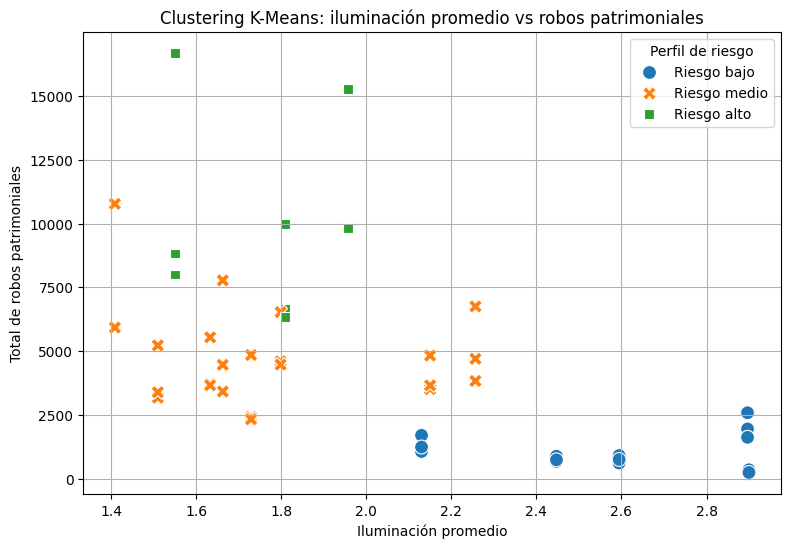

In [30]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_cluster,
    x="iluminacion_promedio",
    y="target_robos_patrimoniales_total",
    hue="perfil_riesgo",
    style="perfil_riesgo",
    s=100
)

plt.title("Clustering K-Means: iluminación promedio vs robos patrimoniales")
plt.xlabel("Iluminación promedio")
plt.ylabel("Total de robos patrimoniales")
plt.grid(True)
plt.legend(title="Perfil de riesgo")
plt.show()

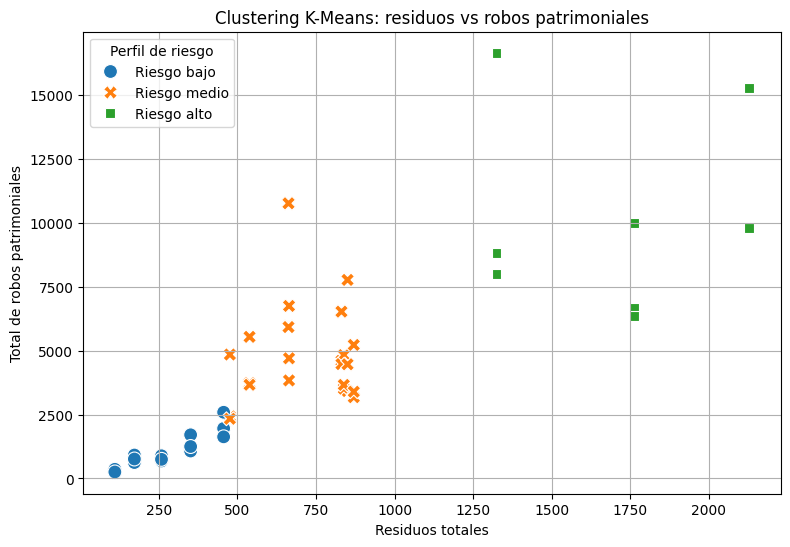

In [31]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_cluster,
    x="residuos_ton_total",
    y="target_robos_patrimoniales_total",
    hue="perfil_riesgo",
    style="perfil_riesgo",
    s=100
)

plt.title("Clustering K-Means: residuos vs robos patrimoniales")
plt.xlabel("Residuos totales")
plt.ylabel("Total de robos patrimoniales")
plt.grid(True)
plt.legend(title="Perfil de riesgo")
plt.show()

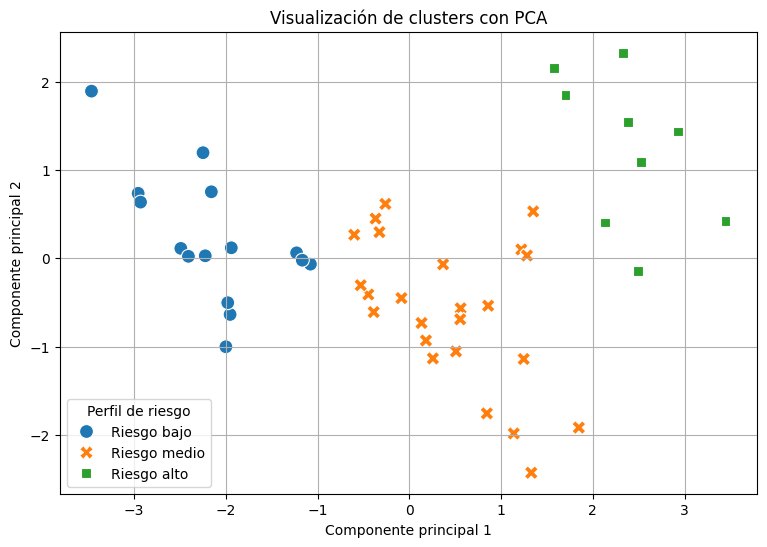

Varianza explicada por PCA: [0.61019645 0.21836316]


In [32]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_cluster["pca_1"] = X_pca[:, 0]
df_cluster["pca_2"] = X_pca[:, 1]

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_cluster,
    x="pca_1",
    y="pca_2",
    hue="perfil_riesgo",
    style="perfil_riesgo",
    s=100
)

plt.title("Visualización de clusters con PCA")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.grid(True)
plt.legend(title="Perfil de riesgo")
plt.show()

print("Varianza explicada por PCA:", pca.explained_variance_ratio_)

In [33]:
eps_values = [0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2]

dbscan_results = []

for eps in eps_values:
    dbscan = DBSCAN(
        eps=eps,
        min_samples=3
    )

    labels = dbscan.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    silhouette = None

    if n_clusters >= 2:
        try:
            silhouette = silhouette_score(X_scaled, labels)
        except ValueError:
            silhouette = None

    dbscan_results.append({
        "eps": eps,
        "clusters_detectados": n_clusters,
        "puntos_ruido": n_noise,
        "silhouette_score": silhouette
    })

df_dbscan_eval = pd.DataFrame(dbscan_results)

display(df_dbscan_eval)

,eps,clusters_detectados,puntos_ruido,silhouette_score
0,0.6,5,32,-0.120233
1,0.8,5,22,0.079207
2,1.0,4,8,0.316804
3,1.2,4,8,0.316804
4,1.4,3,7,0.249066
5,1.6,3,1,0.363174
6,1.8,2,1,0.317852
7,2.0,2,1,0.317852
8,2.2,2,0,0.340001


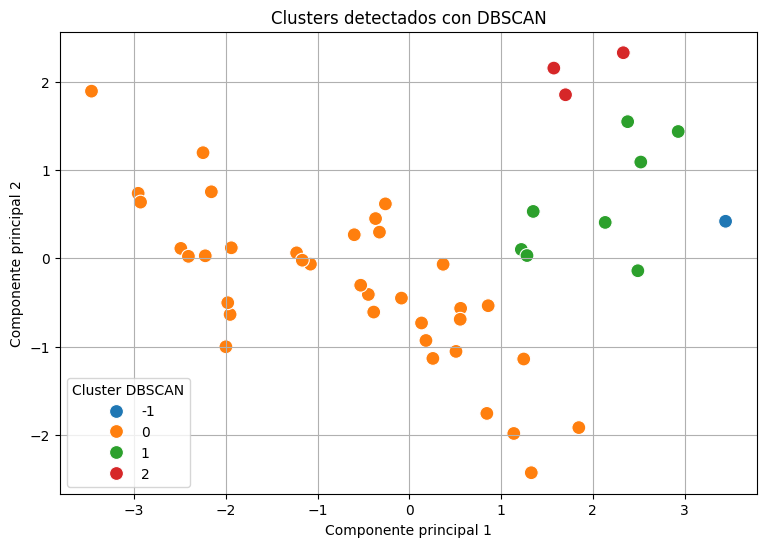

In [36]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_cluster,
    x="pca_1",
    y="pca_2",
    hue="cluster_dbscan",
    palette="tab10",
    s=100
)

plt.title("Clusters detectados con DBSCAN")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.grid(True)
plt.legend(title="Cluster DBSCAN")
plt.show()

In [37]:
comparison = df_cluster[
    [
        "alcaldia_nombre",
        "anio",
        "target_robos_patrimoniales_total",
        "perfil_riesgo",
        "cluster_kmeans",
        "cluster_dbscan"
    ]
].sort_values(["perfil_riesgo", "alcaldia_nombre", "anio"])

display(comparison)

,alcaldia_nombre,anio,target_robos_patrimoniales_total,perfil_riesgo,cluster_kmeans,cluster_dbscan
4,Cuajimalpa De Morelos,2016,623,Riesgo bajo,1,0
20,Cuajimalpa De Morelos,2018,917,Riesgo bajo,1,0
36,Cuajimalpa De Morelos,2020,761,Riesgo bajo,1,0
9,La Magdalena Contreras,2016,685,Riesgo bajo,1,0
25,La Magdalena Contreras,2018,887,Riesgo bajo,1,0
41,La Magdalena Contreras,2020,748,Riesgo bajo,1,0
11,Milpa Alta,2016,224,Riesgo bajo,1,0
27,Milpa Alta,2018,358,Riesgo bajo,1,0
43,Milpa Alta,2020,253,Riesgo bajo,1,0
12,Tlahuac,2016,1074,Riesgo bajo,1,0


In [38]:
OUTPUT_PATH = "/content/drive/MyDrive/DM/analytics/clustering_resultados.csv"

df_cluster.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")

print(f"Archivo exportado correctamente en: {OUTPUT_PATH}")

Archivo exportado correctamente en: /content/drive/MyDrive/DM/analytics/clustering_resultados.csv


In [39]:
import pandas as pd

importancia = pd.DataFrame({
    "variable": ["Iluminación promedio", "NBI ponderado"],
    "importancia": [61.34, 38.66]
})

importancia.to_csv(
    "/content/drive/MyDrive/DM/analytics/importancia_variables.csv",
    index=False,
    encoding="utf-8-sig"
)

In [40]:
tabla_reporte = (
    df_cluster
    .groupby("perfil_riesgo", observed=True)
    .agg(
        observaciones=("perfil_riesgo", "count"),
        robos_promedio=("target_robos_patrimoniales_total", "mean"),
        nbi_promedio=("nbi_wmean", "mean"),
        iluminacion_promedio=("iluminacion_promedio", "mean"),
        residuos_promedio=("residuos_ton_total", "mean"),
        mercados_promedio=("mercados_total", "mean")
    )
    .reset_index()
)

tabla_reporte = tabla_reporte.round(2)

display(tabla_reporte)

,perfil_riesgo,observaciones,robos_promedio,nbi_promedio,iluminacion_promedio,residuos_promedio,mercados_promedio
0,Riesgo bajo,15,1044.40,0.11,2.59,270.22,9.60
1,Riesgo medio,24,4815.96,-0.02,1.77,716.84,21.62
2,Riesgo alto,9,10156.00,0.03,1.77,1737.56,36.33
